# 1. Loading the Nasdaq Data from LSEG


In [2]:
import sys
sys.path.append(r"C:\Users\trund\QRT")
sys.path.append(r"C:\Users\trund\QRT\Strategies")

from backtest.backtesting import Backtester # To backtest the strategy
from sklearn.preprocessing import StandardScaler
import backtest.backtest_results as btr     
import eda

from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import scipy.stats as stats
import yfinance as yf

In [2]:
from get_nasdaq_tickers import get_nasdaq_tickers
from get_MA_warmup_dates import get_rolledback_start

tickers = get_nasdaq_tickers()

ANALYSIS_START, ANALYSIS_END = get_rolledback_start("2015-01-01", "2025-03-31")

data = yf.download(tickers, 
            start=ANALYSIS_START, 
            end=ANALYSIS_END, 
            auto_adjust=False
            )

data.columns = data.columns.set_levels(
        data.columns.levels[0].str.replace(" ", "_"),
        level=0,
        verify_integrity=False,
    )

data.drop(columns=["Open", "High", "Low"])

import pandas as pd



# Identify tickers where any associated column is all NA,

# print them, then drop all columns for those tickers.



flagged_tickers = []
if isinstance(data.columns, pd.MultiIndex):
    # Assume columns are MultiIndex like (field, ticker)
    ticker_level = 1

    for ticker in data.columns.get_level_values(ticker_level).unique():
        sub = data.xs(ticker, level=ticker_level, axis=1)

        # If any column for this ticker is entirely NA, flag it
        if sub.isna().all().any():
            flagged_tickers.append(ticker)

else:
    # Single-level columns: treat each column as its own ticker
    for col in data.columns:
        if data[col].isna().all():
            flagged_tickers.append(col)


print("Tickers with at least one all-NA column:")
print(sorted(flagged_tickers))

# Drop all columns corresponding to the flagged tickers
if flagged_tickers:
    if isinstance(data.columns, pd.MultiIndex):
        data = data.drop(columns=flagged_tickers, level=ticker_level)
    else:
        data = data.drop(columns=flagged_tickers)

print("Data shape after dropping flagged tickers:", data.shape)


Fetching data from: 2014-03-22
Analysis period: 2015-01-01 to 2025-03-31
Extra days for 200-day MA warm-up: ~285 days


$MYL: possibly delisted; no timezone found
[                       0%                       ]$BRCM: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)
[                       1%                       ]  2 of 211 completed$GMCR: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)
[**                     5%                       ]  10 of 211 completed$SOLS: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31) (Yahoo error = "Data doesn't exist for startDate = 1395460800, endDate = 1743393600")
[***                    7%                       ]  15 of 211 completed$SIAL: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)
[******                13%                       ]  28 of 211 completed$CERN: possibly delisted; no timezone found
[*********             19%                       ]  40 of 211 completed$DISCA: possibly delisted; no timezone found
[**********            20%                       ]  42 of 211 complete

Tickers with at least one all-NA column:
['ALTR', 'ALXN', 'ANSS', 'ATVI', 'BRCM', 'CELG', 'CERN', 'CTRP', 'CTRX', 'CTXS', 'DISCA', 'DISCK', 'DISH', 'DTV', 'ENDP', 'FI', 'GMCR', 'KRFT', 'LLTC', 'LMCA', 'LMCK', 'MXIM', 'MYL', 'NDOI', 'NLOK', 'QRTEA', 'SGEN', 'SHPG', 'SIAL', 'SOLS', 'SPLK', 'SPLS', 'SRCL', 'TCFCA', 'TCFCB', 'VIAB', 'VSNT', 'WBA', 'WFM', 'WLTW', 'XLNX', 'YHOO']
Data shape after dropping flagged tickers: (2772, 1014)


In [3]:
checker = eda.loader.data_summary(data)
checker[checker["missing_pct"] > 0]

,dtype,missing_count,missing_pct,unique_values,mean,std,min,max
column,,,,,,,,
"(Adj_Close, ABNB)",float64,1693,61.08,1017,1.396655e+02,2.544560e+01,82.489998,2.168400e+02
"(Adj_Close, APP)",float64,1778,64.14,934,8.115790e+01,9.087170e+01,9.300000,5.101300e+02
"(Adj_Close, ARM)",float64,2386,86.08,377,1.166379e+02,3.675690e+01,47.869999,1.864600e+02
"(Adj_Close, BATRA)",float64,521,18.80,1417,2.884560e+01,7.963700e+00,13.404059,4.734000e+01
"(Adj_Close, BATRK)",float64,521,18.80,1362,2.798600e+01,7.026700e+00,13.004608,4.397000e+01
...,...,...,...,...,...,...,...,...
"(Volume, TEAM)",float64,433,15.62,2221,1.543355e+06,1.179876e+06,0.000000,1.745620e+07
"(Volume, TTD)",float64,630,22.73,2106,9.086434e+06,9.203443e+06,631000.000000,1.276240e+08
"(Volume, VIP)",float64,783,28.25,1823,4.129676e+05,5.705278e+06,0.000000,2.374000e+08


In [4]:
# Split data into training and test 
train_length = int(len(data) * 0.8)
train_data = data.iloc[:train_length -1 ]
test_data = data.iloc[train_length -1 :]

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (2216, 1014)
Test data shape: (556, 1014)


# 2. Winsorisation and Starting New Strategy

In [5]:
import sys 
sys.path.append(r"C:\Users\trund\QRT\Strategies")

from get_nasdaq_tickers import get_nasdaq_tickers
from get_MA_warmup_dates import get_rolledback_start



# To repeatedly call data call + splitting into train and test
def obtain_data():
    tickers = get_nasdaq_tickers()

    ANALYSIS_START, ANALYSIS_END = get_rolledback_start("2015-01-01", "2025-03-31")

    data = yf.download(tickers, 
                start=ANALYSIS_START, 
                end=ANALYSIS_END, 
                auto_adjust=False
                )
    
    return data

def clean_columns(data: pd.DataFrame) -> pd.DataFrame:
    data.columns = data.columns.set_levels(
            data.columns.levels[0].str.replace(" ", "_"),
            level=0,
            verify_integrity=False,
        )
    data.columns = pd.MultiIndex.from_tuples([(column.lower(), ticker) for column, ticker in data.columns])
    
    return data 

def remove_na_tickers(data: pd.DataFrame) -> pd.DataFrame:
    # Identify tickers where any associated column is all NA,
    # print them, then drop all columns for those tickers.
    flagged_tickers = []
    if isinstance(data.columns, pd.MultiIndex):
        # Assume columns are MultiIndex like (field, ticker)
        ticker_level = 1

        for ticker in data.columns.get_level_values(ticker_level).unique():
            sub = data.xs(ticker, level=ticker_level, axis=1)

            # If any column for this ticker is entirely NA, flag it
            if sub.isna().all().any():
                flagged_tickers.append(ticker)

    else:
        # Single-level columns: treat each column as its own ticker
        for col in data.columns:
            if data[col].isna().all():
                flagged_tickers.append(col)

    # Drop all columns corresponding to the flagged tickers
    if flagged_tickers:
        if isinstance(data.columns, pd.MultiIndex):
            data = data.drop(columns=flagged_tickers, level=ticker_level)
        else:
            data = data.drop(columns=flagged_tickers)

    print("Data shape after dropping flagged tickers:", data.shape)
    return data

def add_columns(data: pd.DataFrame) -> pd.DataFrame:
    adj = data.xs("adj_close", level=0, axis=1)     # same as data["adj_close"] if level-0 label exists
    # column-wise returns (per ticker)
    rets = adj.pct_change()                         # NaN only in the first row for each ticker
    # put returns back as a new level-0 field called "returns"
    rets.columns = pd.MultiIndex.from_product([["returns"], rets.columns])
    # join back onto original data
    out = pd.concat([data, rets], axis=1).sort_index(axis=1)
    out.drop(index=data.index[0], inplace=True)  # drop the first row which has NaN returns
    return out

def train_test_split(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_length = int(len(data) * 0.8)
    train_data = data.iloc[:train_length -1 ]
    test_data = data.iloc[train_length -1 :]

    return train_data, test_data


In [6]:
data = obtain_data()
data = clean_columns(data)
data = remove_na_tickers(data)
data = add_columns(data)
main_train_data, main_test_data = train_test_split(data)

$GMCR: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)
[                       0%                       ]$BRCM: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)
[                       1%                       ]  3 of 211 completed

Fetching data from: 2014-03-22
Analysis period: 2015-01-01 to 2025-03-31
Extra days for 200-day MA warm-up: ~285 days


[*                      3%                       ]  7 of 211 completed$MYL: possibly delisted; no timezone found
[**                     4%                       ]  8 of 211 completed$SOLS: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31) (Yahoo error = "Data doesn't exist for startDate = 1395460800, endDate = 1743393600")
[****                   9%                       ]  20 of 211 completed$SIAL: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)
[******                13%                       ]  28 of 211 completed$CERN: possibly delisted; no timezone found
$WBA: possibly delisted; no timezone found
[*********             18%                       ]  37 of 211 completed$DISCA: possibly delisted; no timezone found
[*********             18%                       ]  39 of 211 completed$SGEN: possibly delisted; no timezone found
[***************       31%                       ]  66 of 211 completed$CTXS: possibly delisted; no timezone found
[*

Data shape after dropping flagged tickers: (2772, 1014)


In [7]:
train_data = main_train_data.copy()
data_copy = main_test_data.copy()

In [8]:
train_data_winsorised = eda.winsorise(train_data, columns=[("returns", ticker) for ticker in train_data.columns.get_level_values(1).unique()], lower_pct=0.01, upper_pct=0.99)


print("Winsorised columns:", (train_data_winsorised["returns"].max() < train_data["returns"].max()).sum(), "out of", len(train_data.columns.get_level_values(1).unique()))
# So we can verify that the data was indeed winsorised

Winsorised columns: 166 out of 169


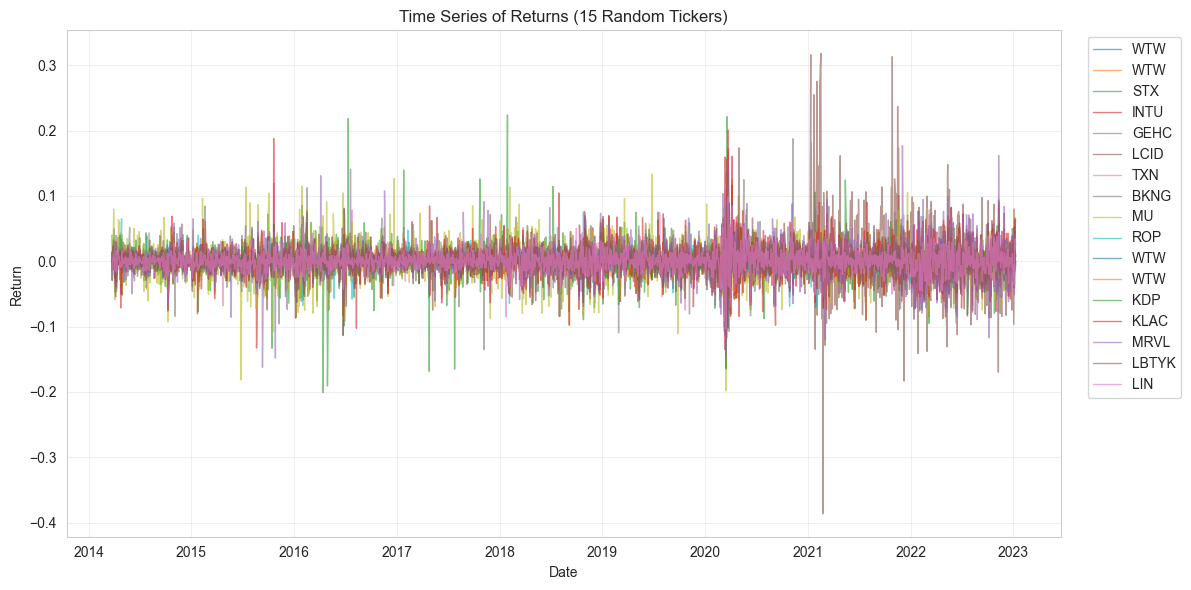

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# This is the code before


# 1. Retrieve the unique list of 'pure' tickers from Level 1 of the MultiIndex
# We use level=1 because level=0 is your category ('prices', 'volume')
all_tickers = train_data.columns.get_level_values(1).unique()

# 2. Use np.random.randint to generate 15 random indices
# We pick numbers between 0 and the total number of tickers
np.random.seed(41)
random_indices = np.random.randint(0, len(all_tickers), 15)

# Select the tickers corresponding to these indices
selected_tickers = all_tickers[random_indices]

# 3. Slice the dataframe for 'prices' and the selected tickers, then calculate returns
# Note: Accessing data_copy['prices'] drops the top level, leaving tickers as columns
returns_df = train_data['returns'][selected_tickers]
returns_df_winsorised = train_data_winsorised['returns'][selected_tickers]

# 4. Plot the time series on the same plot
plt.figure(figsize=(12, 6))

# Plot each ticker column
for ticker in returns_df.columns:
    plt.plot(returns_df.index, returns_df[ticker], label=ticker, alpha=0.6, linewidth=1)

plt.title("Time Series of Returns (15 Random Tickers)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # Places legend outside to avoid clutter
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

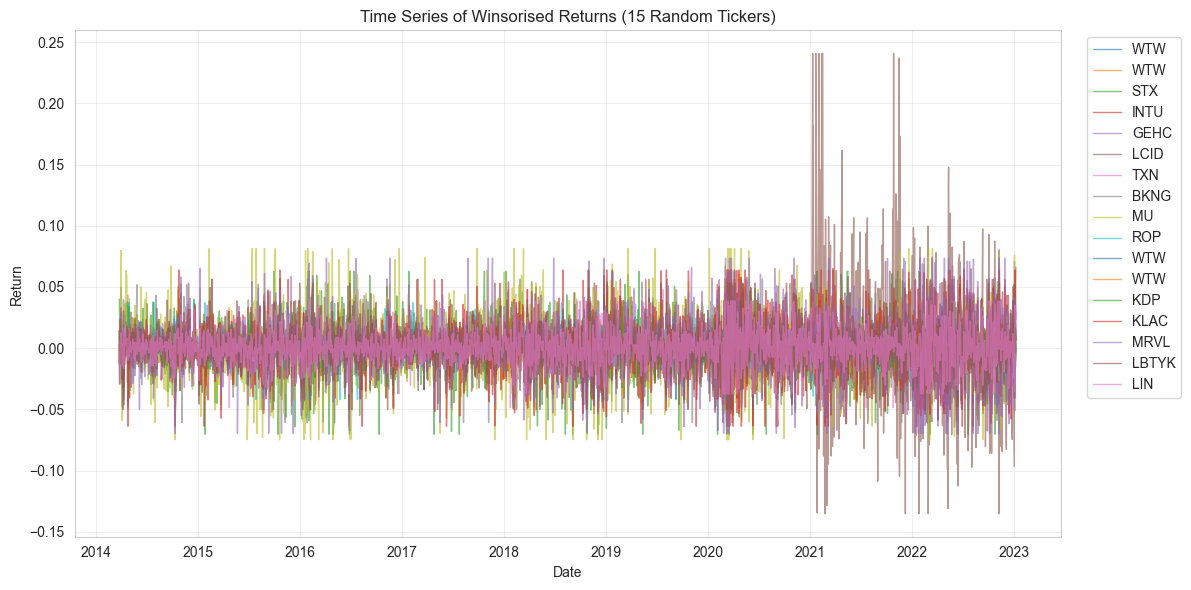

In [10]:
# Plot each ticker column
plt.figure(figsize=(12, 6))
for ticker in returns_df_winsorised.columns:
    plt.plot(returns_df_winsorised.index, returns_df_winsorised[ticker], label=ticker, alpha=0.6, linewidth=1)

plt.title("Time Series of Winsorised Returns (15 Random Tickers)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # Places legend outside to avoid clutter
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Starting Strategy

In [3]:
import obtain_data_helper as odh

data = odh.obtain_data()
data = odh.clean_columns(data)
data = odh.remove_na_tickers(data)
data = odh.add_columns(data)
main_train_data, main_test_data = odh.train_test_split(data)


Fetching data from: 2014-03-22
Analysis period: 2015-01-01 to 2025-03-31
Extra days for 200-day MA warm-up: ~285 days


[****                   8%                       ]  17 of 211 completed$SPLS: possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31) (Yahoo error = "Data doesn't exist for startDate = 1395460800, endDate = 1743393600")
[******                12%                       ]  25 of 211 completed$MYL: possibly delisted; no timezone found
[******                13%                       ]  28 of 211 completed$DTV: possibly delisted; no timezone found
[********              17%                       ]  35 of 211 completed$CERN: possibly delisted; no timezone found
$TCFCA: possibly delisted; no timezone found
[**********            20%                       ]  42 of 211 completed$CELG: possibly delisted; no timezone found
[************          24%                       ]  50 of 211 completed$LMCK: possibly delisted; no timezone found
[************          24%                       ]  51 of 211 completed$QRTEA: possibly delisted; no timezone found
[************          25%      

Data shape after dropping flagged tickers: (2772, 1014)


In [12]:
train_data = main_train_data.copy()
train_data = eda.outliers.winsorise(train_data, columns=[("returns", ticker) for ticker in train_data.columns.get_level_values(1).unique()], lower_pct=0.01, upper_pct=0.99)

# Handle NaN values 

tradable_assets = train_data.columns.get_level_values(1).unique().tolist()
prices = train_data["adj_close"].copy()

test_data = main_test_data.copy()
test_data = eda.outliers.winsorise(test_data, columns=[("returns", ticker) for ticker in test_data.columns.get_level_values(1).unique()], lower_pct=0.01, upper_pct=0.99)

In [13]:
from backtest.strategy import Strategy
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

class FactorModelStrat(Strategy):
    def __init__(self, rolling_window: int = 15, rebalance_frequency: int = 1, top_bottom_pct: float = 0.1):
        super().__init__()
        self.rolling_window = rolling_window
        self.rebalance_frequency = rebalance_frequency
        self.top_bottom_pct = top_bottom_pct
        
    def _get_raw_signals(self, tradable_assets, history):
        """1. Obtains the raw signal from the linear regression"""

        if len(history) < self.rolling_window + 1:
            return pd.Series(0.0, index=tradable_assets)
            
        if 'returns' not in history.columns.levels[0]:
            returns_df = history['adj_close'][tradable_assets].pct_change()
        else:
            returns_df = history['returns'][tradable_assets]

        
        # Calculate mean. Setting skipna=False explicitly forces the calculation 
        # to yield NaN if there are any NaNs in the window, exactly as requested.
        rolling_mean_train = returns_df.iloc[-self.rolling_window - 1:-1].mean(skipna=False)
        rolling_mean_test = returns_df.iloc[-self.rolling_window:].mean(skipna=False)

        # Removed the dummy returns used in previous verification step. 
        epsilon = 1e-8
        
        # cross-sectional mean 
        mean_val_train = rolling_mean_train.mean(skipna=True)
        std_val_train = rolling_mean_train.std(skipna=True)

        mean_z_scored_train = ((rolling_mean_train - mean_val_train) / 
                  (std_val_train + epsilon)).values.reshape(-1, 1)
        
        target_train = returns_df.iloc[-1]
        mean_val_target = target_train.mean(skipna=True)
        std_val_target = target_train.std(skipna=True)
        target_z_scored_train = ((target_train - mean_val_target) / (std_val_target + epsilon)).values
        

        # Explicitly align the validity mapping across the cross-section
        # A ticker is only valid for regression fitting if BOTH its past rolling mean (z_past) 
        # AND its past return (y_past) are valid.
        valid_idx = pd.Index((~np.isnan(mean_z_scored_train.flatten())) & (~np.isnan(target_z_scored_train)))
        if not np.any(valid_idx):
            return pd.Series(0.0, index=tradable_assets)
        

        model = LinearRegression(fit_intercept=True).fit(mean_z_scored_train[valid_idx], target_z_scored_train[valid_idx])
        
        # Now prepare the current features for prediction
        
        mean_val_test = rolling_mean_test.mean()
        std_val_test = rolling_mean_test.std()
        mean_z_scored_test = ((rolling_mean_test - mean_val_test) / (std_val_test + epsilon)).values.reshape(-1, 1) # variable names here were not good 
        
        signal = np.zeros(len(tradable_assets))
        
        # Determine valid assets for prediction right now
        # An asset can only be predicted if its current feature (z_now) is NOT NaN
        z_valid_idx = ~np.isnan(mean_z_scored_test.flatten())
        
        if np.any(z_valid_idx):
            signal[z_valid_idx] = model.predict(mean_z_scored_test[z_valid_idx])
            
        signals = pd.Series(signal, index=tradable_assets)
        
        latest_prices = history['adj_close'][tradable_assets].iloc[-1]
        signals[latest_prices.isna()] = 0.0
        
        return signals

    def _get_long_short_signals(self, raw_signals):
        """2. Converts the raw signals into long-short candidate indices"""
        # Drop NaN upfront so all subsequent logic operates on clean values
        raw_signals = raw_signals.dropna()

        long_signals = raw_signals[raw_signals > 0]
        short_signals = raw_signals[raw_signals < 0]

        n_long_assets = len(long_signals)
        n_short_assets = len(short_signals)

        # Guard: if one leg is empty, return an empty index for that leg rather
        # than forcing k=1 via max(1, ...) and then silently selecting nothing.
        if n_long_assets == 0 and n_short_assets == 0:
            return pd.Index([]), pd.Index([])

        # Ensure at least one asset per non-empty leg
        k_long = max(1, int(n_long_assets * self.top_bottom_pct)) if n_long_assets > 0 else 0
        k_short = max(1, int(n_short_assets * self.top_bottom_pct)) if n_short_assets > 0 else 0

        long_candidates = long_signals.sort_values(ascending=False).head(k_long).index
        short_candidates = short_signals.sort_values(ascending=True).head(k_short).index

        # Guard assertions only when the candidate set is non-empty to avoid
        # NaN comparisons on empty Series (e.g. empty.min() → NaN > 0 → False)
        if len(long_candidates) > 0:
            assert raw_signals[long_candidates].min() > 0, "Long candidates contain non-positive signals"
        if len(short_candidates) > 0:
            assert raw_signals[short_candidates].max() < 0, "Short candidates contain non-negative signals"

        return long_candidates, short_candidates

    def _get_mcap(self, ticker, last_row):
        """Helper to safely calculate the market cap of a given ticker."""
        try:
            high = last_row.get(('high', ticker), last_row.get(('High', ticker), np.nan))
            low = last_row.get(('low', ticker), last_row.get(('Low', ticker), np.nan))
            vol = last_row.get(('volume', ticker), last_row.get(('Volume', ticker), np.nan))
            
            mid_price = 0.5 * (high + low)
            
            if np.isnan(mid_price):
                mid_price = last_row.get(('adj_close', ticker), last_row.get(('Adj Close', ticker), np.nan))
                
            if np.isnan(mid_price) or np.isnan(vol):
                return 0.0
            return max(0.0, mid_price * vol)
        except Exception:
            return 0.0

    def _compute_value_weights(self, tradable_assets, long_candidates, short_candidates, history):
        """3. Computes the value-weightings for long and short legs separately"""
        weights = pd.Series(0.0, index=tradable_assets)
        last_row = history.iloc[-1]
        
        # Long leg value weights
        if len(long_candidates) > 0:
            long_mcaps = pd.Series({t: self._get_mcap(t, last_row) for t in long_candidates})
            sum_long_mcap = long_mcaps.sum()
            if sum_long_mcap > 0:
                # Error handling in the case that the weights are too small 
                weights[long_mcaps.index] = np.maximum((long_mcaps / sum_long_mcap) * 0.5, 0.0)

        # Raise Exception if any of the long candidates have non-zero values:
        if (weights[long_candidates] < 0).any():
            raise ValueError("Negative weights found in long candidates")
        
        # Short leg value weights
        if len(short_candidates) > 0:
            short_mcaps = pd.Series({t: self._get_mcap(t, last_row) for t in short_candidates})
            sum_short_mcap = short_mcaps.sum()
            if sum_short_mcap > 0:
                weights[short_mcaps.index] = np.minimum((short_mcaps / sum_short_mcap) * -0.5, 0.0)

        # Raise Exception if any of the short candidates have non-zero values:
        if (weights[short_candidates] > 0).any():
            raise ValueError("Positive weights found in short candidates")
                
        return weights

    def predict(self, tradable_assets, history, trading_state):
        if len(history) % self.rebalance_frequency != 0:
            return None
            
        if len(history) < self.rolling_window:
            return None
            
        # 1. Gather raw signals
        raw_signals = self._get_raw_signals(tradable_assets, history)
        
        # 2. Convert to long-short boundaries
        long_candidates, short_candidates = self._get_long_short_signals(raw_signals)
        
        if len(long_candidates) == 0 and len(short_candidates) == 0:
            return None
            
        # 3. Compute Value weightings
        weights = self._compute_value_weights(tradable_assets, long_candidates, short_candidates, history)
        
        # 4. Generate Target
        target_asset_amount = weights * trading_state.current_nav
        
        return target_asset_amount


## Basic tests for strategy helpers



These are assert-based notebook tests. They are simpler than using the `unittest` module, but they follow the same principle: construct controlled inputs, run one function, and assert the exact behaviour you expect.

### Tests for _get_long_short_weights

In [ ]:
test_strat = FactorModelStrat(top_bottom_pct=0.6)

# --- Test 1: Normal mixed signals ---
# 3 positive, 2 negative. k_long = max(1, int(3*0.6)) = max(1,1) = 1... wait
# int(3*0.6)=1, int(2*0.6)=1 → k_long=1, k_short=1
# Use top_bottom_pct=1.0 to keep all so overlap handling is more interesting
test_strat_all = FactorModelStrat(top_bottom_pct=1.0)
raw_mixed = pd.Series(
    [5.0, 4.0, 3.0, -2.0, -1.0],
    index=["A", "B", "C", "D", "E"],
)
lc, sc = test_strat_all._get_long_short_signals(raw_mixed)
assert set(lc).isdisjoint(set(sc)), f"Overlap found: {set(lc) & set(sc)}"
assert set(lc) == {"A", "B", "C"}, f"Unexpected longs: {set(lc)}"
assert set(sc) == {"D", "E"}, f"Unexpected shorts: {set(sc)}"
print("Test 1 passed: normal mixed signals → correct disjoint longs and shorts.")

# --- Test 2: All-positive signals (no short leg) ---
raw_all_positive = pd.Series([3.0, 2.0, 1.0], index=["A", "B", "C"])
lc2, sc2 = test_strat_all._get_long_short_signals(raw_all_positive)
assert len(sc2) == 0, f"Expected empty short candidates, got: {list(sc2)}"
assert len(lc2) > 0, f"Expected non-empty long candidates"
print("Test 2 passed: all-positive signals → empty short leg, no assertion error.")

# --- Test 3: All-negative signals (no long leg) ---
raw_all_negative = pd.Series([-3.0, -2.0, -1.0], index=["A", "B", "C"])
lc3, sc3 = test_strat_all._get_long_short_signals(raw_all_negative)
assert len(lc3) == 0, f"Expected empty long candidates, got: {list(lc3)}"
assert len(sc3) > 0, f"Expected non-empty short candidates"
print("Test 3 passed: all-negative signals → empty long leg, no assertion error.")

# --- Test 4: All-zero signals (both legs empty) ---
raw_zeros = pd.Series([0.0, 0.0, 0.0], index=["A", "B", "C"])
lc4, sc4 = test_strat_all._get_long_short_signals(raw_zeros)
assert len(lc4) == 0 and len(sc4) == 0, "Expected both legs empty for all-zero signals"
print("Test 4 passed: all-zero signals → both legs empty, no assertion error.")

# --- Test 5: NaN values are dropped before processing ---
raw_with_nan = pd.Series([5.0, np.nan, -3.0, np.nan], index=["A", "B", "C", "D"])
lc5, sc5 = test_strat_all._get_long_short_signals(raw_with_nan)
assert "B" not in lc5 and "B" not in sc5, "NaN asset 'B' should not appear in any candidate"
assert "D" not in lc5 and "D" not in sc5, "NaN asset 'D' should not appear in any candidate"
print("Test 5 passed: NaN signals are dropped and do not appear in any candidate set.")


Test 1 passed: normal mixed signals → correct disjoint longs and shorts.
Test 2 passed: all-positive signals → empty short leg, no assertion error.
Test 3 passed: all-negative signals → empty long leg, no assertion error.
Test 4 passed: all-zero signals → both legs empty, no assertion error.
Test 5 passed: NaN signals are dropped and do not appear in any candidate set.


## Suggested tests for `_compute_value_weights`



Good tests beyond checking for non-zero weights:



1. Long-only leg sums to `0.5` when long market caps are positive.

2. Short-only leg sums to `-0.5` when short market caps are positive.

3. Assets that are in neither basket keep weight `0.0`.

4. Every long candidate has a non-negative weight and every short candidate has a non-positive weight.

5. If long and short baskets are both present, total portfolio weight sums to approximately `0.0`.

6. Weights are proportional to estimated market caps within each leg.

7. If every market cap in one leg is zero, that leg stays at all zeros instead of dividing by zero.

8. No `NaN` values appear in the returned weight series.



If you want, the next step is to turn 2 to 4 of these into executable notebook tests using a tiny mock `history` dataframe.

In [ ]:
# Test: _compute_value_weights should produce no NA values in active legs,
 
# long weights should sum to 0.5, and neutral assets should stay at 0.0
 
test_strat = FactorModelStrat(top_bottom_pct=0.1)
 
tradable_assets = ["A", "B", "C", "D", "E"]
long_candidates = pd.Index(["A", "B"])

short_candidates = pd.Index(["C", "D"])

neutral_assets = [asset for asset in tradable_assets if asset not in long_candidates and asset not in short_candidates]



# Build a one-row history with deterministic positive market-cap proxies

history_columns = pd.MultiIndex.from_product(

    [["high", "low", "volume", "adj_close"], tradable_assets]

)

history = pd.DataFrame(

    [[

        11.0, 21.0, 31.0, 41.0, 51.0,  # high

        9.0, 19.0, 29.0, 39.0, 49.0,   # low

        100.0, 200.0, 300.0, 400.0, 500.0,  # volume

        10.0, 20.0, 30.0, 40.0, 50.0,  # adj_close

    ]],

    columns=history_columns,

)



weights = test_strat._compute_value_weights(

    tradable_assets,

    long_candidates,

    short_candidates,
    history,
)



assert weights[long_candidates].notna().all(), (
    f"Found NA in long weights: {weights[long_candidates]}"

)

assert weights[short_candidates].notna().all(), (

    f"Found NA in short weights: {weights[short_candidates]}"

)

assert np.isclose(weights[long_candidates].sum(), 0.5), (

    f"Expected long weights to sum to 0.5, got {weights[long_candidates].sum()}"

)

assert (weights[neutral_assets] == 0.0).all(), (

    f"Expected neutral assets to have zero weights, got {weights[neutral_assets]}"

)



print("Test passed: active-leg weights contain no NAs, long weights sum to 0.5, and neutral assets stay at 0.0.")

weights

# Backtesting


In [17]:
data = test_data.copy()
tradable_assets = data.columns.get_level_values(1).unique().tolist()
prices = data["adj_close"].copy()

backtest_factor_model = Backtester(
    tradable_assets=tradable_assets,
    strategy_fn=FactorModelStrat(rolling_window=30, rebalance_frequency=3, top_bottom_pct=0.10),
    strategy_name="Fama-Macbeth Regression",
    data=data,
    prices=prices,
    execute_on_next_tick=True,
    slippage=0.005, 
    commission=0.005
)

backtest_factor_model.run()

import backtest.backtest_results as btr
from backtest.benchmarks import BuyAndHold
from backtest.backtest_results import VisualiseBacktestResults

backtest_buy_and_hold = Backtester(tradable_assets=tradable_assets, strategy_fn=BuyAndHold(100000), strategy_name="Buy and Hold", data=data, prices=prices)
backtest_buy_and_hold.run()


In [35]:
signal_history = pd.Series(backtest_factor_model.signal_history)
signal_history[~signal_history.isna()][32]


AAL       0.000000
AAPL      0.000000
ABNB      0.000000
ADBE      0.000000
ADI       0.000000
           ...    
WYNN      0.000000
XEL       0.000000
XRAY      0.000000
ZM        0.000000
ZS      191.230339
Length: 164, dtype: float64

Strategy Visualisation


In [18]:
backtest_results = VisualiseBacktestResults(backtest_factor_model, backtest_buy_and_hold, riskfree_rate=0)

backtest_results.calculate_alpha_versus_benchmark()

Constant term of the regression: 0.0 

NB: The alpha value is given in the constant term. 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 16 Mar 2026   Prob (F-statistic):                nan
Time:                        13:55:23   Log-Likelihood:                    inf
No. Observations:                 555   AIC:                              -inf
Df Residuals:                     553   BIC:                              -inf
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

c:\Users\trund\QRT\venv313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\trund\QRT\venv313\Lib\site-packages\statsmodels\regression\linear_model.py:1871: RuntimeWarning: invalid value encountered in scalar divide
  return self.mse_model/self.mse_resid
c:\Users\trund\QRT\venv313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\trund\QRT\venv313\Lib\site-packages\statsmodels\stats\stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
  dw = np.sum(diff_resids**2, axis=axis) / np.sum(resids**2, axis=axis)


C:\Users\trund\QRT\backtest\backtest_results.py:90: RuntimeWarning: invalid value encountered in scalar divide
  self._strategy_metrics["sharpe"] = returns.mean() / returns.std() * np.sqrt(252)  # Annualized Sharpe Ratio
C:\Users\trund\QRT\backtest\backtest_results.py:98: RuntimeWarning: invalid value encountered in scalar divide
  self._strategy_metrics["calmar"] = returns.mean() / abs(self._strategy_metrics["max_drawdown"])


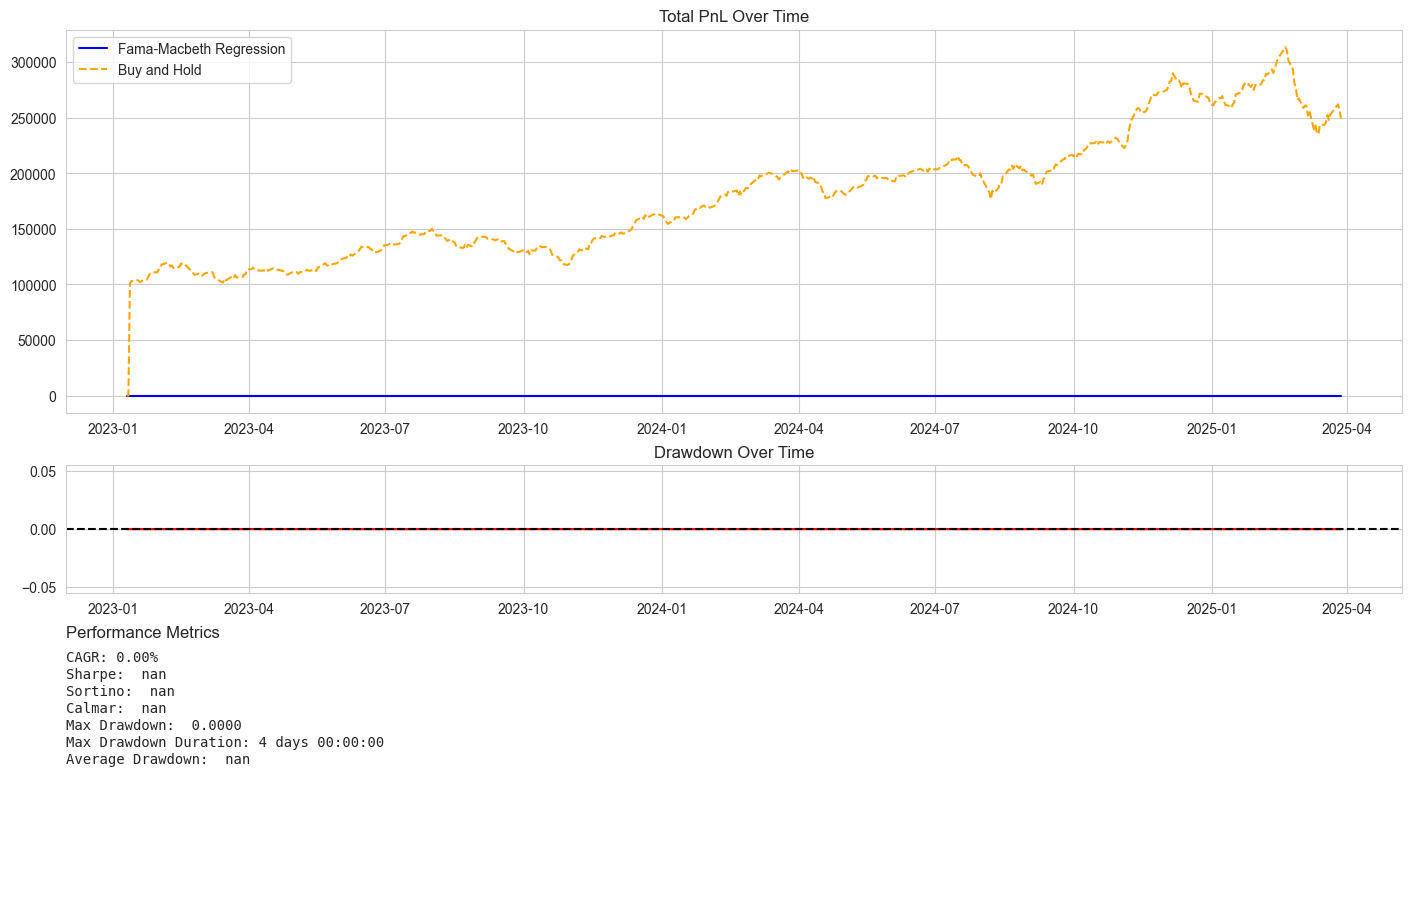

In [16]:
backtest_results.performance_dashboard()

# 4. Export Dummy Targets For QRT

Build a QRT-compatible dummy targets dataframe directly from `tradable_assets`. This version longs the first 10 tradable tickers and shorts the next 10 with fixed notionals, then prepares a CSV for upload.

In [43]:
from pathlib import Path
import sys

qsec_client_root = Path(r"C:\Users\trund\QRT\qsec-client")
if str(qsec_client_root) not in sys.path:
    sys.path.append(str(qsec_client_root))

from qsec_client.sample_code import prepare_targets_file, upload_targets_file, validate_targets_file, Region


def build_dummy_targets_from_tradable_assets(
    tradable_assets: list[str],
    long_count: int = 10,
    short_count: int = 10,
    long_notional: float = 100000.0,
    short_notional: float = -100000.0,
    default_currency: str = "USD",
) -> pd.DataFrame:
    if len(tradable_assets) < long_count + short_count:
        raise ValueError(
            f"Need at least {long_count + short_count} tradable assets, got {len(tradable_assets)}"
        )

    long_assets = tradable_assets[:long_count]
    short_assets = tradable_assets[long_count : long_count + short_count]

    targets = pd.DataFrame(
        {
            "ticker": long_assets + short_assets,
            "internal_code": long_assets + short_assets,
            "currency": [default_currency] * (long_count + short_count),
            "target_notional": [long_notional] * long_count + [short_notional] * short_count,
        }
    )

    return targets


latest_targets = build_dummy_targets_from_tradable_assets(
    tradable_assets=tradable_assets,
    long_count=10,
    short_count=10,
    long_notional=100000.0,
    short_notional=-100000.0,
    default_currency="USD",
)

print(f"Tradable assets available: {len(tradable_assets)}")
print(f"Dummy targets rows: {len(latest_targets)}")
latest_targets

Tradable assets available: 169
Dummy targets rows: 20


,ticker,internal_code,currency,target_notional
0,AAL,AAL,USD,100000.0
1,AAPL,AAPL,USD,100000.0
2,ABNB,ABNB,USD,100000.0
3,ADBE,ADBE,USD,100000.0
4,ADI,ADI,USD,100000.0
5,ADP,ADP,USD,100000.0
6,ADSK,ADSK,USD,100000.0
7,AEP,AEP,USD,100000.0
8,AKAM,AKAM,USD,100000.0
9,ALGN,ALGN,USD,100000.0


In [44]:
group_id = "OXON13"  # replace with your assigned QRT group id
region = Region.AMER  # or Region.EMEA
output_dir = Path(r"C:\Users\trund\QRT\qsec-client\targets_out")
output_dir.mkdir(parents=True, exist_ok=True)

targets_csv_path = prepare_targets_file(
    latest_targets,
    group_id=group_id,
    region=region,
    output_dir=output_dir,
)

validation_errors = validate_targets_file(targets_csv_path)
print(f"Prepared file: {targets_csv_path}")
print(f"Validation errors: {len(validation_errors)}")
validation_errors

Found 0 error(s) while validating C:\Users\trund\QRT\qsec-client\targets_out\qrt_academy_OXON13_20260316-1407.csv
Prepared file: C:\Users\trund\QRT\qsec-client\targets_out\qrt_academy_OXON13_20260316-1407.csv
Validation errors: 0


[]

In [45]:
# Optional: only run this after you have confirmed the generated CSV is correct.
# Fill in the credentials QRT gave you before running.

sftp_username = "q9243"  # replace
private_key_path = Path(r"C:\Users\trund\QRT\qsec-client\qsec_client\oxon13_id_rsa")  # replace
sftp_host = "sftp.qrt.cloud"

upload_targets_file(
    targets_csv_path=targets_csv_path,
    region=region,
    sftp_username=sftp_username,
    private_key_path=private_key_path,
    sftp_host=sftp_host,
)

Found 0 error(s) while validating C:\Users\trund\QRT\qsec-client\targets_out\qrt_academy_OXON13_20260316-1407.csv
Reading private key from: C:\Users\trund\QRT\qsec-client\qsec_client\oxon13_id_rsa
Connecting to sftp.qrt.cloud:22
Logging in as q9243
Uploading C:\Users\trund\QRT\qsec-client\targets_out\qrt_academy_OXON13_20260316-1407.csv to incoming/amer/qrt_academy_OXON13_20260316-1407.csv
File 'C:\Users\trund\QRT\qsec-client\targets_out\qrt_academy_OXON13_20260316-1407.csv' successfully uploaded to AMER.
